Nesse notebook, aplicaremos as técnicas de agrupamento, o Kmeans e o DBSCAN

função auxiliar pras métricas:

In [1]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

def avaliar_cluster(nome_modelo, modelo, X, labels):
    """
    Função padronizada para avaliar modelos de Clusterização.
    """
    # Contar quantos clusters válidos existem (ignorando o rótulo -1, que é ruído no DBSCAN)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    print(f"--- Resultados: {nome_modelo} ---")
    print(f"Número de Clusters encontrados: {n_clusters}")
    
    if n_clusters < 2:
        print("Aviso: Menos de 2 clusters válidos encontrados. As métricas não podem ser calculadas.")
        return {'Modelo': nome_modelo, 'Silhouette': None, 'Davies_Bouldin': None, 'Calinski_Harabasz': None}
    
    # Cálculos das métricas
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    # Tentando capturar a inércia (se existir no modelo)
    inercia = getattr(modelo, 'inertia_', 'N/A')
    
    # Exibição
    if inercia != 'N/A':
        print(f"Inércia            (↓ Menor é melhor): {inercia:.4f}")
    else:
        print(f"Inércia            (↓ Menor é melhor): {inercia} (Não aplicável ao algoritmo)")
        
    print(f"Silhouette Score   (↑ Maior é melhor): {sil:.4f}  (Mede coesão vs separação. Vai de -1 a 1)")
    print(f"Calinski-Harabasz  (↑ Maior é melhor): {ch:.4f}  (Mede dispersão entre clusters vs dentro deles)")
    print(f"Davies-Bouldin     (↓ Menor é melhor): {db:.4f}  (Mede o quão parecidos os clusters são entre si)")
    print("-" * 50)
    
    return {
        'Modelo': nome_modelo,
        'K_Clusters': n_clusters,
        'Inercia': inercia,
        'Silhouette': sil,
        'Calinski_Harabasz': ch,
        'Davies_Bouldin': db
    }

Comparativo da quantidade de clusters:

In [2]:
from sklearn.cluster import KMeans
import pandas as pd

# Recuperar o X de treino que já está com PCA e sem os IDs
X_train_full = pd.read_csv('./CSVs/X_train_pca.csv')
colunas_id = ['TEAM_ID', 'SEASON_ID']
X_train = X_train_full.drop(columns=colunas_id)
X_cluster = X_train.copy()

resultados_kmeans = []

print("Buscando o melhor K para o K-Means...\n")

# Testar K de 2 até 10
for k in range(2, 11):
    # Inicializar e treinar o K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_cluster)
    
    # Usar a nossa função auxiliar
    metricas = avaliar_cluster(f"K-Means (K={k})", kmeans, X_cluster, labels)
    resultados_kmeans.append(metricas)

# transformar a lista em DataFrame para ver a tabela resumida no final
df_resultados = pd.DataFrame(resultados_kmeans)
print("\n--- Resumo de todas as execuções ---")
display(df_resultados)

Buscando o melhor K para o K-Means...

--- Resultados: K-Means (K=2) ---
Número de Clusters encontrados: 2
Inércia            (↓ Menor é melhor): 5308.3342
Silhouette Score   (↑ Maior é melhor): 0.3002  (Mede coesão vs separação. Vai de -1 a 1)
Calinski-Harabasz  (↑ Maior é melhor): 430.7159  (Mede dispersão entre clusters vs dentro deles)
Davies-Bouldin     (↓ Menor é melhor): 1.2815  (Mede o quão parecidos os clusters são entre si)
--------------------------------------------------
--- Resultados: K-Means (K=3) ---
Número de Clusters encontrados: 3
Inércia            (↓ Menor é melhor): 4150.1548
Silhouette Score   (↑ Maior é melhor): 0.2595  (Mede coesão vs separação. Vai de -1 a 1)
Calinski-Harabasz  (↑ Maior é melhor): 386.5576  (Mede dispersão entre clusters vs dentro deles)
Davies-Bouldin     (↓ Menor é melhor): 1.2950  (Mede o quão parecidos os clusters são entre si)
--------------------------------------------------
--- Resultados: K-Means (K=4) ---
Número de Clusters encontra

,Modelo,K_Clusters,Inercia,Silhouette,Calinski_Harabasz,Davies_Bouldin
0,K-Means (K=2),2,5308.334186,0.300183,430.715895,1.281467
1,K-Means (K=3),3,4150.154760,0.259455,386.557590,1.295015
2,K-Means (K=4),4,3598.301559,0.241713,337.651040,1.255842
3,K-Means (K=5),5,3366.345697,0.191182,284.077484,1.483541
4,K-Means (K=6),6,2972.090759,0.203548,278.204120,1.365661
5,K-Means (K=7),7,2838.207413,0.186679,248.718196,1.463394
6,K-Means (K=8),8,2672.140740,0.179429,233.200519,1.501699
7,K-Means (K=9),9,2570.110655,0.162322,215.818937,1.577233
8,K-Means (K=10),10,2483.791420,0.163460,201.313982,1.502444


Método do cotovelo:

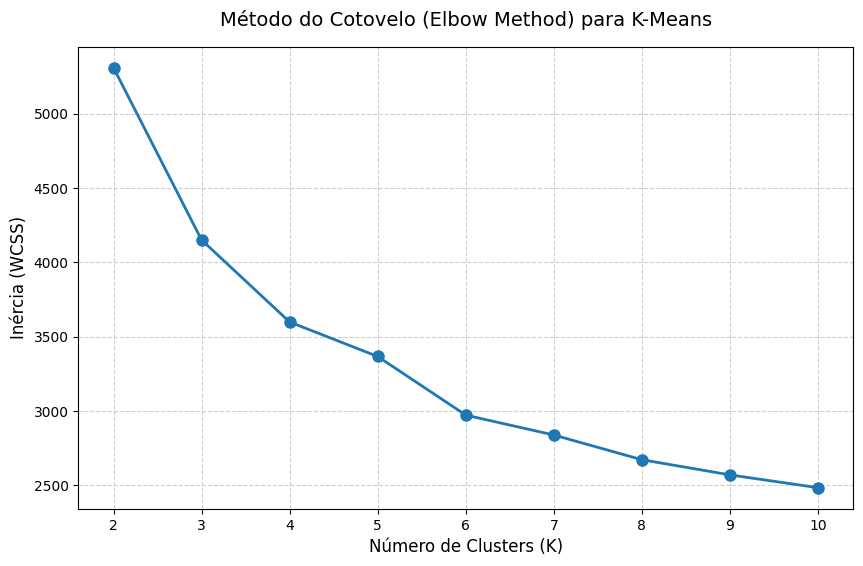

In [3]:
import matplotlib.pyplot as plt

# Recuperando os dados da nossa tabela de resultados
k_values = df_resultados['K_Clusters']
inercia_values = df_resultados['Inercia']

# Criando o gráfico do Método do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_values, inercia_values, marker='o', linestyle='-', color='tab:blue', linewidth=2, markersize=8)

plt.title('Método do Cotovelo (Elbow Method) para K-Means', fontsize=14, pad=15)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia (WCSS)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Levando em conta que é nesse K que tem a melhor métrica de Davis-Bouldin, e ele parece ser onde o cotovelo acontece no gráfico, escolheremos o K = 4.

Aplicação e visualização de fato, tendo em mente a escolha:

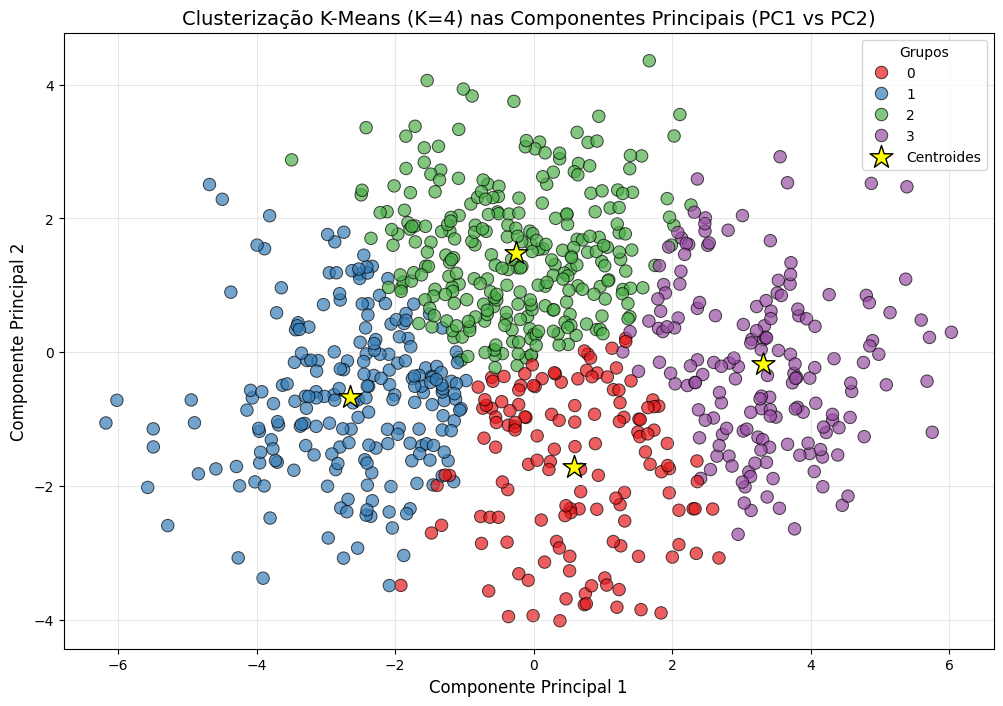

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# escolha do K = 4
K_IDEAL = 4

# Treinar o K-Means final
kmeans_final = KMeans(n_clusters=K_IDEAL, random_state=42, n_init='auto')
clusters_kmeans = kmeans_final.fit_predict(X_cluster)

# Adicionar os rótulos dos clusters de volta ao DataFrame para o gráfico
# Como o X_cluster só tem os PCs, vamos criar um df temporário para visualização
df_vis = X_cluster.copy()
df_vis['Cluster'] = clusters_kmeans

# Criar o Gráfico de Dispersão 2D (Usando PC1 e PC2)
plt.figure(figsize=(12, 8))

# O seaborn é ótimo para colorir categorias automaticamente (hue='Cluster')
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Set1', # Paleta de cores bem distintas
    data=df_vis, 
    s=80, 
    alpha=0.7, 
    edgecolor='k'
)

# Adicionando os centroides (os "corações" matemáticos de cada cluster)
centroides = kmeans_final.cluster_centers_
plt.scatter(
    centroides[:, 0], 
    centroides[:, 1], 
    c='yellow', 
    s=300, 
    marker='*', 
    edgecolor='black', 
    label='Centroides'
)

plt.title(f'Clusterização K-Means (K={K_IDEAL}) nas Componentes Principais (PC1 vs PC2)', fontsize=14)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Grupos')
plt.grid(True, alpha=0.3)
plt.show()

Começando o DBSCAN:

In [5]:
from sklearn.cluster import DBSCAN

print("Buscando a melhor configuração para o DBSCAN...\n")

# Vamos testar alguns valores para o raio (eps) e vizinhos (min_samples)
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]

resultados_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        
        # Inicializar e treinar o DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_cluster)
        
        # Ignorar resultados onde todos são ruídos ou há apenas 1 cluster
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters >= 2:
            # Avaliar usando nossa função padronizada
            metricas = avaliar_cluster(f"DBSCAN (eps={eps}, min_samp={min_samples})", dbscan, X_cluster, labels)
            resultados_dbscan.append(metricas)

if not resultados_dbscan:
    print("Nenhuma das configurações gerou mais de 1 cluster válido. Tente aumentar o 'eps' ou diminuir o 'min_samples'.")
else:
    df_dbscan = pd.DataFrame(resultados_dbscan)
    print("\n--- Resumo DBSCAN ---")
    display(df_dbscan.sort_values(by='Silhouette', ascending=False))

Buscando a melhor configuração para o DBSCAN...

--- Resultados: DBSCAN (eps=0.5, min_samp=3) ---
Número de Clusters encontrados: 6
Inércia            (↓ Menor é melhor): N/A (Não aplicável ao algoritmo)
Silhouette Score   (↑ Maior é melhor): -0.4599  (Mede coesão vs separação. Vai de -1 a 1)
Calinski-Harabasz  (↑ Maior é melhor): 1.2723  (Mede dispersão entre clusters vs dentro deles)
Davies-Bouldin     (↓ Menor é melhor): 2.4993  (Mede o quão parecidos os clusters são entre si)
--------------------------------------------------
--- Resultados: DBSCAN (eps=1.0, min_samp=3) ---
Número de Clusters encontrados: 17
Inércia            (↓ Menor é melhor): N/A (Não aplicável ao algoritmo)
Silhouette Score   (↑ Maior é melhor): -0.3616  (Mede coesão vs separação. Vai de -1 a 1)
Calinski-Harabasz  (↑ Maior é melhor): 4.8313  (Mede dispersão entre clusters vs dentro deles)
Davies-Bouldin     (↓ Menor é melhor): 2.5014  (Mede o quão parecidos os clusters são entre si)
---------------------------

,Modelo,K_Clusters,Inercia,Silhouette,Calinski_Harabasz,Davies_Bouldin
2,"DBSCAN (eps=1.0, min_samp=5)",7,N/A,-0.232119,20.473816,2.134979
1,"DBSCAN (eps=1.0, min_samp=3)",17,N/A,-0.361630,4.831300,2.501357
0,"DBSCAN (eps=0.5, min_samp=3)",6,N/A,-0.459945,1.272288,2.499281


Visualização:

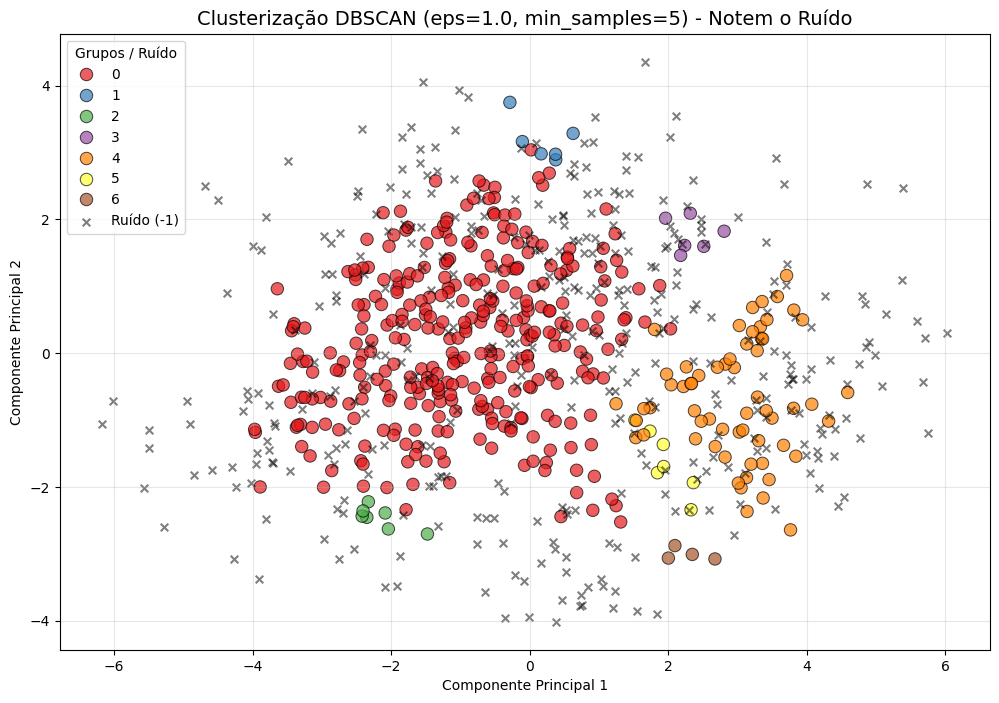

In [6]:
# Treinar o DBSCAN com a melhor configuração que achamos
dbscan_final = DBSCAN(eps=1.0, min_samples=5)
clusters_dbscan = dbscan_final.fit_predict(X_cluster)

# Adicionar ao DataFrame de visualização
df_vis_dbscan = X_cluster.copy()
df_vis_dbscan['Cluster'] = clusters_dbscan

# Criar o Gráfico de Dispersão 2D
plt.figure(figsize=(12, 8))

# Vamos separar os ruídos (-1) dos clusters normais
ruido = df_vis_dbscan[df_vis_dbscan['Cluster'] == -1]
clusters_validos = df_vis_dbscan[df_vis_dbscan['Cluster'] != -1]

# Plotar os clusters válidos usando a paleta do seaborn
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Set1', 
    data=clusters_validos, 
    s=80, 
    alpha=0.7, 
    edgecolor='k',
    legend='full'
)

# Plotar o Ruído (-1) em preto/cinza escuro e menor
plt.scatter(
    ruido['PC1'], 
    ruido['PC2'], 
    c='black', 
    s=30, 
    alpha=0.5, 
    label='Ruído (-1)',
    marker='x'
)

plt.title('Clusterização DBSCAN (eps=1.0, min_samples=5) - Notem o Ruído', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupos / Ruído')
plt.grid(True, alpha=0.3)
plt.show()

Além da métrica de Silhouette ser negativa(péssima), a visualização do DBSCAN é um gráfico sem nenhum sentido claro, o que mostra que o K-means é muito superior pra esse problema.

Silhouette Plot:

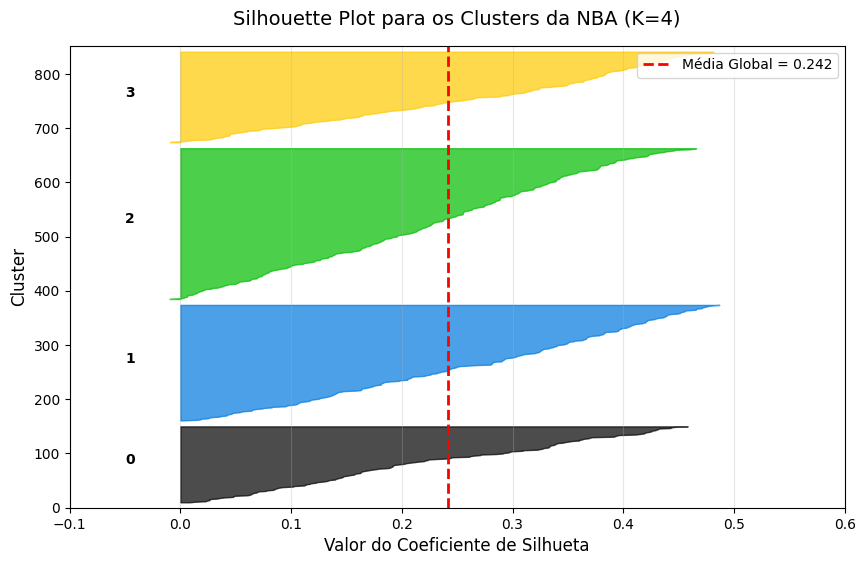

In [7]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

# Recriar o nosso melhor modelo (K=4)
K_IDEAL = 4
kmeans_sil = KMeans(n_clusters=K_IDEAL, random_state=42, n_init='auto')
cluster_labels = kmeans_sil.fit_predict(X_cluster)

# Calcular a média global e os valores individuais
silhouette_avg = silhouette_score(X_cluster, cluster_labels)
sample_silhouette_values = silhouette_samples(X_cluster, cluster_labels)

# Configurar o gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))
# O eixo X vai de -0.1 a 1 (limites do silhouette)
ax1.set_xlim([-0.1, 0.6]) 
ax1.set_ylim([0, len(X_cluster) + (K_IDEAL + 1) * 10])

y_lower = 10

# Desenhar a silhueta de cada cluster
for i in range(K_IDEAL):
    # Agregar e ordenar os scores dos times que pertencem ao cluster i
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Escolher uma cor baseada no mapa de cores
    color = cm.nipy_spectral(float(i) / K_IDEAL)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Colocar o número do cluster no eixo Y
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')

    # Calcular o próximo y_lower para o próximo cluster
    y_lower = y_upper + 10  # 10 é o espaço em branco entre as 'lâminas'

ax1.set_title(f"Silhouette Plot para os Clusters da NBA (K={K_IDEAL})", fontsize=14, pad=15)
ax1.set_xlabel("Valor do Coeficiente de Silhueta", fontsize=12)
ax1.set_ylabel("Cluster", fontsize=12)

# A linha vertical vermelha é a Média Global
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2, label=f'Média Global = {silhouette_avg:.3f}')

ax1.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='x')
plt.show()